In [1]:
from lets_plot import *


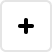
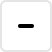
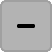
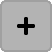
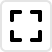
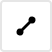
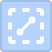
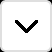
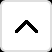
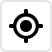
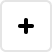
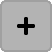
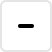
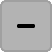
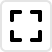
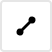
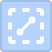
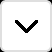
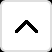
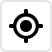

In [2]:
LetsPlot.setup_html()

In [3]:
d = { 'v': [0.34447] }

p = ggplot(d, aes('v','v')) + geom_point(tooltips = layer_tooltips().line('^y')) 
p

#### Set scale format

[Issue LPK 229](https://github.com/JetBrains/lets-plot-kotlin/issues/229): Nice to have tooltip to inherit formatting configured for axis


In [4]:
# Continuous scale: format is applied to tooltips

p + scale_y_continuous(format="scale={.3f}")

In [5]:
# Specified labels cancel format

p + scale_y_continuous(format="scale={.3f}", breaks=[0.2,0.5],labels=['0.2','0.5'])

In [6]:
# Discrete scale: formatted label breaks are used for tooltips

p + scale_y_discrete(format="scale={.3f}")

#### Set tooltip format

In [7]:
p2 = ggplot(d, aes('v','v')) + geom_point(tooltips = layer_tooltips().line('^y').format('^y','tooltip={.1f}'))
p2

#### Both: set tooltip and scale formats

Tooltip format() is also applied to the axis tooltip.

In [8]:
gggrid([
    p2 + scale_y_continuous(format="scale={.3f}"),
    p2 + scale_y_discrete(format="scale={.3f}"),
])

#### Use variable in tooltip

In [9]:
# default format

ggplot(d) + geom_point(aes('v','v'), tooltips = layer_tooltips().line('@v')) 

In [10]:
# Add format for the variable

gggrid([
    ggplot(d) + geom_point(aes('v','v'), tooltips = layer_tooltips().line('^y').format("v", "tooltip={.1f}")),
    ggplot(d) + geom_point(aes('v','v'), tooltips = layer_tooltips().line('@v').format("v", "tooltip={.1f}"))
])

#### Use `'{}'` in tooltip format

[Issue #484](https://github.com/JetBrains/lets-plot/issues/484): '{}' in format pattern should use the default formatting

In [11]:
ggplot(d, aes('v','v')) + geom_point(tooltips = layer_tooltips().line('^y').format('^y','tooltip={}'))

In [12]:
ggplot(d, aes('v','v')) + \
     geom_point(tooltips = layer_tooltips().line('^y').format('^y','tooltip={}')) + \
     scale_y_continuous(format="scale={}")

In [13]:
# Log10

ggplot(d) + \
    geom_point(aes('v','v'), tooltips = layer_tooltips().line('^y') .format('^y', 'tooltips={}')) + \
    scale_y_log10(format='scale={}')

In [14]:
# Example from the issue

N = 21
x = [v for v in range(N)]
y0 = [pow(10, v / 10.) for v in range(N)]
y1 = [v * 5 for v in range(N)]
formula = ['10^(x/10)'] * N + ['5*x'] * N
data2 = dict(x=x * 2, y=y0 + y1, formula=formula)

ggplot(data2) + geom_point(aes('x', 'y', color='formula')) +  scale_y_log10()

In [15]:
# after specifying the format for the y-axis tooltip:

ggplot(data2) + \
    geom_point(aes('x', 'y', color='formula'),
              tooltips=layer_tooltips().line('^y').format('^y', '{} %')) + \
    scale_y_log10()

#### DateTime

In [16]:
import pandas as pd
from datetime import datetime

# datetime

economics_url = 'https://raw.githubusercontent.com/JetBrains/lets-plot-docs/master/data/economics.csv'
economics = pd.read_csv(economics_url)
economics['date'] = pd.to_datetime(economics['date'])
start = datetime(2000, 1, 1)
economics = economics.loc[economics['date'] >= start]

In [17]:
p3 = (ggplot(economics, aes('date', 'uempmed')) + geom_line() )
p3 + scale_x_datetime()

In [18]:
p3 + scale_x_datetime(format="%b %Y") 

In [19]:
p3 + scale_x_datetime(format="in %b %Y") 

In [20]:
(ggplot(economics, aes('date', 'uempmed')) + 
 scale_x_datetime() + 
 geom_line(tooltips=layer_tooltips()
               .line('^x')
               .anchor("top_left")
               .min_width(170))
)

In [21]:
(ggplot(economics, aes('date', 'uempmed')) + 
 scale_x_datetime() +
 geom_line(tooltips=layer_tooltips()
               .line('^x')
               .format('date', 'in %b %Y')
               .anchor("top_left")
               .min_width(170))
)

In [22]:
(ggplot(economics, aes('date', 'uempmed')) + 
 scale_x_datetime() +
 geom_line(tooltips=layer_tooltips()
               .line('@date')
               .format('^x', 'in %b %Y')
               .anchor("top_left")
               .min_width(170))
)